In [ ]:
!pip install copernicusmarine


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 6.4 MB/s eta 0:00:00


Example Code

In [ ]:

"""
This script shows how you can use the copernicusmarine library to obtain ocean data
that corresponds to an event. The process can be scaled up to match data to many
individual events to identify ocean conditions that correlate with an outcome of
interest.
"""
import copernicusmarine
from datetime import timedelta
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd



In [ ]:
copernicusmarine.login(
    username = "sng",
    password = "Copernicus1!",
)

INFO - 2026-09-15T16:15:00Z - Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.
INFO:copernicusmarine:Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.


True

In [ ]:
# Define a hypothetical event we want to match data to
EVENT_NAME = "Chilean salmon mortality"
EVENT_DATE = datetime.strptime("2023-02-12", "%Y-%m-%d")
tolerance = timedelta(hours=12)
EVENT_LAT = -43.81
EVENT_LON = -73.66

In [ ]:
###  Define data set to access ###
# This is the Copernicus Marine global ocean physics reanalysis
ds = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
)

# Select the variable, region, and date of interest. This stays lazy: nothing is
# downloaded until a compute step below forces it.
region = ds["thetao"].sel(
    longitude=slice(EVENT_LON-1.0, EVENT_LON+1.0),
    latitude=slice(EVENT_LAT-1.0, EVENT_LAT+1.0),
    time=EVENT_DATE,
    depth=slice(0,1.0)
)


INFO - 2026-09-15T16:15:03Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-09-15T16:15:03Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


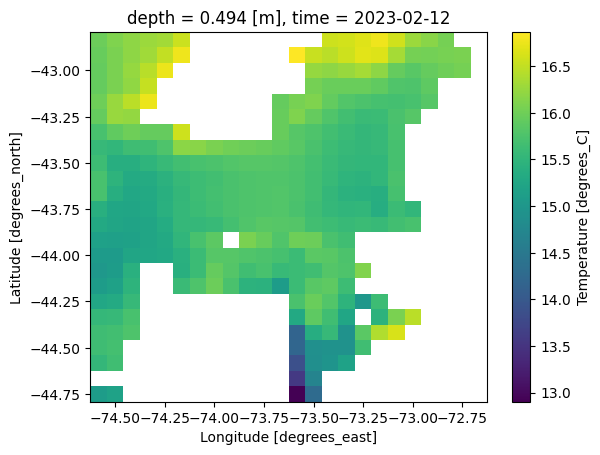

In [ ]:
# Plot the data for the date of interest
region.plot(cmap='viridis')
plt.savefig("example_sst.png")


In [ ]:
# Calculate statistics over the selected region and time
print("Average temperature",region.mean().compute().item())
print("99th percentile of temperature", region.quantile(0.99).compute().item())

Average temperature 15.70819964602312
99th percentile of temperature 16.757492603212594


In [ ]:
# Format start and end dates to be Windows-friendly (no colons)
start_str = (EVENT_DATE - tolerance).strftime("%Y%m%d_%H%M")
end_str = (EVENT_DATE + tolerance).strftime("%Y%m%d_%H%M")

output_file = f"{EVENT_NAME}_{start_str}_{end_str}_sst.nc"
output_path = Path("copernicusmarine") / output_file

if output_path.exists():
    print("Data already loaded")
else:
    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
        variables=["thetao"],  # temperature
        minimum_longitude=EVENT_LON - 0.5,
        maximum_longitude=EVENT_LON + 0.5,
        minimum_latitude=EVENT_LAT - 0.5,
        maximum_latitude=EVENT_LAT + 0.5,
        start_datetime=EVENT_DATE - tolerance,
        end_datetime=EVENT_DATE + tolerance,
        minimum_depth=0,
        maximum_depth=1,  # extract surface conditions
        coordinates_selection_method="nearest",
        output_directory="copernicusmarine",
        output_filename=output_file,
    )

INFO - 2026-09-15T16:15:34Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-09-15T16:15:34Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-15T16:15:34Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-15T16:15:37Z - Total size of the download: 13.97 KB.
INFO:copernicusmarine:Total size of the download: 13.97 KB.


<xarray.Dataset> Size: 3kB
Dimensions:    (time: 2, depth: 1, latitude: 13, longitude: 13)
Coordinates:
  * time       (time) datetime64[ns] 16B 2023-02-12 2023-02-13
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 52B -44.33 -44.25 -44.17 ... -43.42 -43.33
  * longitude  (longitude) float32 52B -74.17 -74.08 -74.0 ... -73.25 -73.17
Data variables:
    thetao     (time, depth, latitude, longitude) float64 3kB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min

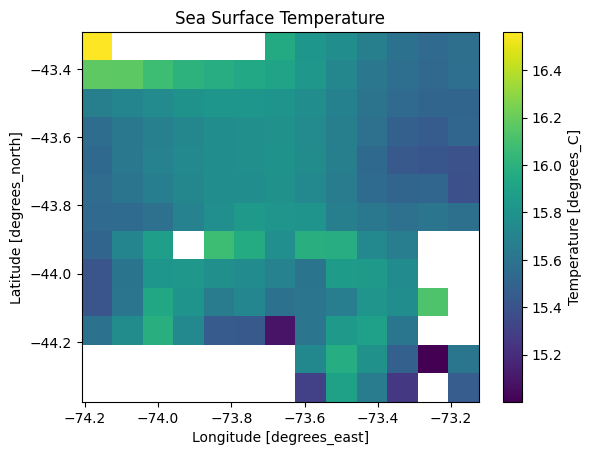

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# Load the saved NetCDF file
file_path = Path("copernicusmarine") / output_file
ds = xr.open_dataset(file_path)

# Print summary to inspect dimensions and variables
print(ds)

# Plot sea surface temperature for the first time step
ds["thetao"].isel(time=0).plot(cmap='viridis')
plt.title("Sea Surface Temperature")
plt.show()

Data Loading

In [ ]:
# Saves data into json file
# !copernicusmarine describe> all_products_copernicus_marine_service.json


In [ ]:
import pandas as pd

hae_url = "https://raw.githubusercontent.com/Break-Through-Tech/Oregon-State-University-1A-forecasting-risk-of-harmful-algal-blooms-in-coastal-marine-ecosystems/main/data/raw/harmful_algae_events.csv"

HAE_data = pd.read_csv(hae_url)

HAE_data.head()

/tmp/ipykernel_1000/3139742227.py:5: DtypeWarning: Columns (6,19,48,62) have mixed types. Specify dtype option on import or set low_memory=False.
  HAE_data = pd.read_csv(hae_url)


,Event ID,Event Name,Year,Country,Region,Status,Submitter,Created At,Updated At,Event Date,...,Advected Info,Stratification Info,Nutrients,Additional Env Info,Additional Harmful Effect Info,Additional Bloom Info,Management Decision,Economic Losses,References,Contacts
0,14822,NO-26-015,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Harvesting was locally banned. The public was ...,Unknown,NaN,Mona Ring Kleiven
1,14819,NO-26-012,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Harvesting was locally banned. The public was ...,Unknown,NaN,Mona Ring Kleiven
2,14810,NO-26-003,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-05-18,2026-05-18,NaN,...,0-3 m,NaN,NaN,NaN,NaN,NaN,Fish farms warned,NaN,NaN,Mona Ring Kleiven
3,14821,NO-26-014,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Harvesting was locally banned. The public was ...,Unknown,NaN,Mona Ring Kleiven
4,14812,NO-26-005,2026,NORWAY,Region 12 (EUR),Submitted,mona.ring.kleiven@hi.no,2026-06-22,2026-06-22,2026-04-06,...,NaN,NaN,NaN,NaN,NaN,NaN,Harvesting was locally banned. The public was ...,Unknown,NaN,Mona Ring Kleiven


In [ ]:
list(ds.data_vars)

['thetao']

Addressing Missing Values & Outliers

In [ ]:
df = pd.DataFrame(HAE_data)

# Missing Summary
missing_summary = pd.DataFrame({
    "missing_amt": df.isna().sum(),
    "missing_pct": df.isna().mean()
})
missing_summary

,missing_amt,missing_pct
Event ID,0,0.000000
Event Name,0,0.000000
Year,0,0.000000
Country,0,0.000000
Region,13856,0.982625
...,...,...
Additional Bloom Info,13932,0.988015
Management Decision,10152,0.719949
Economic Losses,13286,0.942203
References,11947,0.847245


In [ ]:
print("Duplicate rows:", df.duplicated().sum()) #There are no duplicates
df.describe(include = "all")

Duplicate rows: 0


,Event ID,Event Name,Year,Country,Region,Status,Submitter,Created At,Updated At,Event Date,...,Advected Info,Stratification Info,Nutrients,Additional Env Info,Additional Harmful Effect Info,Additional Bloom Info,Management Decision,Economic Losses,References,Contacts
count,14101.000000,14101,14101.000000,14101,245,14101,17,10819,3188,7761,...,835,1758.000000,0.0,596,1764,169,3949,815,2154,13801
unique,NaN,14101,NaN,106,15,2,3,1043,482,4650,...,335,NaN,NaN,455,1101,163,1337,545,1183,540
top,NaN,AU-70-001,NaN,FRENCH POLYNESIA,Region 12 (EUR),Approved,mona.ring.kleiven@hi.no,2018-09-27,2019-12-03,2020-11-27,...,Sampling aprox 0-3 meters,NaN,NaN,Sampling aprox 0-3 meters,http://www.intecmar.gal/Informacion/biotoxinas...,A slight halocline was observed,Harvesting was locally banned. The public was ...,Mussel plants were banned from harvesting.,More details in China Disaster Bulletin,"GATTI, Clémence"
freq,NaN,1,NaN,3968,63,14084,15,154,179,38,...,146,NaN,NaN,39,145,3,459,59,116,3964
mean,7628.603503,NaN,2008.732147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.118885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4245.972102,NaN,10.346621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.323745,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,1770.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4132.000000,NaN,2002.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,7721.000000,NaN,2009.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,11293.000000,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
HAE_data[
    HAE_data["Event Date"].isna()
][["Region", "Event Date", "Start Date", "End Date"]]

,Region,Event Date,Start Date,End Date
0,Region 12 (EUR),NaN,2026-05-04,2026-06-01
1,Region 12 (EUR),NaN,2026-04-20,2026-06-01
2,Region 12 (EUR),NaN,2026-04-20,2026-05-04
3,Region 12 (EUR),NaN,2026-04-20,2026-06-15
5,Region 12 (EUR),NaN,2026-04-06,2026-05-18
...,...,...,...,...
14091,NaN,NaN,1936-01-01,1936-01-31
14092,NaN,NaN,1916-11-01,1916-12-31
14093,NaN,NaN,1910-11-01,1911-01-31
14096,NaN,NaN,1901-01-01,1901-01-31


Dropped values that have empty dates or latitude/longitude as that is needed


In [ ]:

HAE_clean = HAE_data.copy()

no_date_mask = (
    HAE_clean["Event Date"].isna() &
    HAE_clean["Start Date"].isna() &
    HAE_clean["End Date"].isna()
)

print("Rows with no temporal information:", no_date_mask.sum())

HAE_clean = HAE_clean[~no_date_mask].copy()
HAE_clean = HAE_clean.dropna(subset=["Latitude", "Longitude"]).copy()

print("Original rows:", len(HAE_data))
print("Cleaned rows:", len(HAE_clean))

Rows with no temporal information: 3836
Original rows: 14101
Cleaned rows: 10243


In [ ]:
print("Latitude range:", HAE_clean["Latitude"].min(), "to", HAE_clean["Latitude"].max())
print("Longitude range:", HAE_clean["Longitude"].min(), "to", HAE_clean["Longitude"].max())

Latitude range: -78.383333 to 82.233333
Longitude range: -808.8684 to 177.288889


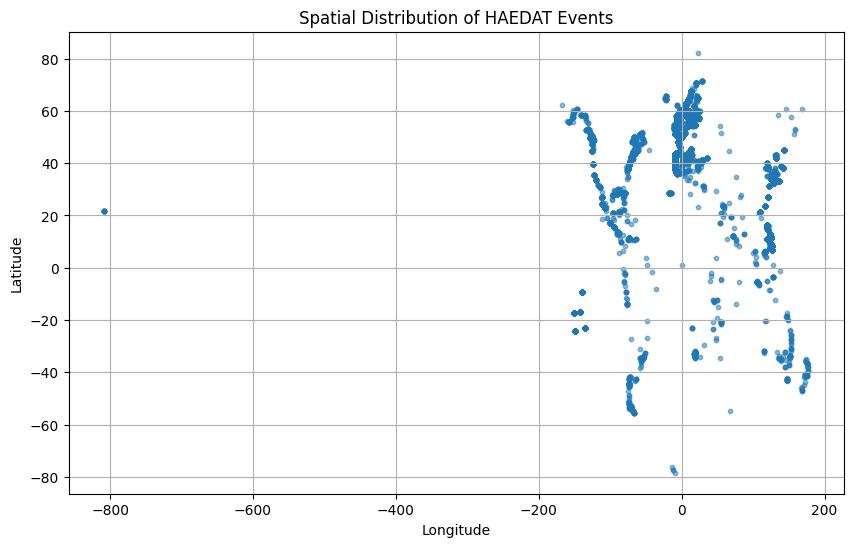

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(HAE_clean["Longitude"], HAE_clean["Latitude"], alpha=0.5, s=10)
plt.title("Spatial Distribution of HAEDAT Events")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [ ]:
extreme_lon_rows = HAE_clean[HAE_clean["Longitude"] < -180]
print(extreme_lon_rows[["Latitude", "Longitude", "Country", "Region", "Event Date", "Start Date", "End Date"]])
#Noticed incorrect longitude, decimal should be shifted back

       Latitude  Longitude Country Region  Event Date  Start Date    End Date
961     21.7187  -808.8684  MEXICO    NaN  2022-08-18  2022-05-01  2022-09-04
4237    21.7187  -808.8684  MEXICO    NaN         NaN  2015-07-07  2015-07-30
4240    21.7187  -808.8684  MEXICO    NaN         NaN  2015-09-09  2015-09-29
6307    21.7187  -808.8684  MEXICO    NaN         NaN  2011-10-15  2011-10-18
6318    21.7187  -808.8684  MEXICO    NaN         NaN  2011-07-22  2011-12-16
8083    21.7187  -808.8684  MEXICO    NaN         NaN  2008-06-04  2008-06-05
8088    21.7187  -808.8684  MEXICO    NaN         NaN  2008-06-23  2008-07-10
10382   21.7187  -808.8684  MEXICO    NaN         NaN  2003-07-25  2003-08-10


In [ ]:
mask = (HAE_clean["Longitude"] < -180) & (HAE_clean["Longitude"] > -900)

HAE_clean.loc[mask, "Longitude"] = HAE_clean.loc[mask, "Longitude"] / 10
print(HAE_clean[HAE_clean["Latitude"] == 21.7187][["Latitude", "Longitude", "Country"]])

       Latitude  Longitude Country
961     21.7187  -80.88684  MEXICO
4237    21.7187  -80.88684  MEXICO
4240    21.7187  -80.88684  MEXICO
6307    21.7187  -80.88684  MEXICO
6318    21.7187  -80.88684  MEXICO
8083    21.7187  -80.88684  MEXICO
8088    21.7187  -80.88684  MEXICO
10382   21.7187  -80.88684  MEXICO


**Statistics (Mayowa)**

In [ ]:
#STATS
import numpy as np
import pandas as pd
import xarray as xr
import copernicusmarine
import matplotlib.pyplot as plt

In [ ]:
# Copernicus global ocean physics reanalysis
PHYSICS_DATASET_ID = "cmems_mod_glo_phy_my_0.083deg_P1D-m"

# Start with temperature and salinity
PHYSICS_VARIABLES = [
    "thetao",  # Sea water temperature
    "so"       # Sea water salinity
]

# Use a 1-degree box around each event location
BUFFER_DEGREES = 1.0

# Copernicus data are daily, so allow a difference of up to one day
MAX_TIME_DIFFERENCE = pd.Timedelta(days=1)

In [ ]:
physics_ds = copernicusmarine.open_dataset(
    dataset_id=PHYSICS_DATASET_ID,
    variables=PHYSICS_VARIABLES
)

physics_ds

INFO - 2026-09-15T16:15:41Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-09-15T16:15:41Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


<xarray.Dataset> Size: 86TB
Dimensions:    (depth: 50, latitude: 2041, longitude: 4320, time: 12227)
Coordinates:
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.83 89.92 90.0
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
  * time       (time) datetime64[ns] 98kB 1993-01-01 1993-01-02 ... 2026-06-23
Data variables:
    thetao     (time, depth, latitude, longitude) float64 43TB dask.array<chunksize=(50, 2, 512, 2048), meta=np.ndarray>
    so         (time, depth, latitude, longitude) float64 43TB dask.array<chunksize=(50, 2, 512, 2048), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1